In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/vessel_arrival_delay_clean.csv")

df.head()

,Voyage_ID,Carrier,Vessel_Name,Vessel_Type,Origin_Port,Destination_Port,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Season,Customs_Clearance_Risk,Actual_Delay_Hours,Late_Arrival
0,V14846,COSCO,Mary Voyager,Bulk Carrier,Hamburg,Los Angeles,4659,16.1,1.7,14.4,19,88.6,45.70,5.2,805.550,1.1,Spring,Medium,16.6,1
1,V14121,Yang Ming,David Voyager,LNG Carrier,Los Angeles,Antwerp,5571,13.7,8.6,13.9,10,55.9,47.90,6.4,539.090,7.9,Autumn,Low,24.4,1
2,V14861,COSCO,Heather Voyager,Bulk Carrier,Singapore,Mumbai,3422,8.9,0.3,12.3,22,95.3,0.30,9.2,650.760,12.6,Spring,Low,26.9,1
3,V00885,ONE,Rachel Voyager,Oil Tanker,Colombo,Mumbai,1300,4.0,5.9,17.7,25,96.1,50.15,4.9,651.745,8.0,Summer,High,25.2,1
4,V00412,CMA CGM,Karen Voyager,Container,Busan,Shanghai,11140,42.2,18.9,15.6,15,64.0,41.30,6.2,669.180,3.2,Autumn,High,29.9,1


In [17]:
df["Route"] = (
    df["Origin_Port"] +
    " → " +
    df["Destination_Port"]
)

In [18]:
def congestion_level(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"


df["Congestion_Level"] = pd.cut(
    df["Port_Congestion_Index"],
    bins=[-1, 30, 70, 100],
    labels=["Low", "Medium", "High"]
)

In [19]:
def weather_category(score):

    if score <= 3:
        return "Clear"

    elif score <= 6:
        return "Moderate"

    else:
        return "Severe"


df["Weather_Category"] = df["Weather_Severity"].apply(weather_category)

In [20]:
def vessel_age_group(age):

    if age <= 5:
        return "New"

    elif age <= 15:
        return "Mid Age"

    else:
        return "Old"


df["Vessel_Age_Group"] = df["Vessel_Age"].apply(vessel_age_group)

In [21]:
def load_category(load):

    if load < 60:
        return "Low"

    elif load < 85:
        return "Medium"

    else:
        return "High"


df["Load_Category"] = df["Cargo_Load_Percentage"].apply(load_category)

In [22]:
def speed_category(speed):

    if speed < 15:
        return "Slow"

    elif speed < 20:
        return "Normal"

    else:
        return "Fast"


df["Speed_Category"] = df["Average_Speed_Knots"].apply(speed_category)

In [23]:
df["Delay_Risk_Score"] = (
    df["Departure_Delay_Hours"] * 0.4
    + df["Weather_Severity"] * 0.3
    + df["Port_Congestion_Index"] * 0.3
)

In [24]:
new_features = [
    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category",
    "Delay_Risk_Score"
]

df[new_features].head()

,Route,Congestion_Level,Weather_Category,Vessel_Age_Group,Load_Category,Speed_Category,Delay_Risk_Score
0,Hamburg → Los Angeles,Medium,Moderate,Old,High,Slow,15.950
1,Los Angeles → Antwerp,Medium,Severe,Mid Age,Low,Slow,19.730
2,Singapore → Mumbai,Low,Severe,Old,High,Slow,2.970
3,Colombo → Mumbai,Medium,Moderate,Old,High,Normal,18.875
4,Busan → Shanghai,Medium,Severe,Mid Age,Medium,Normal,21.810


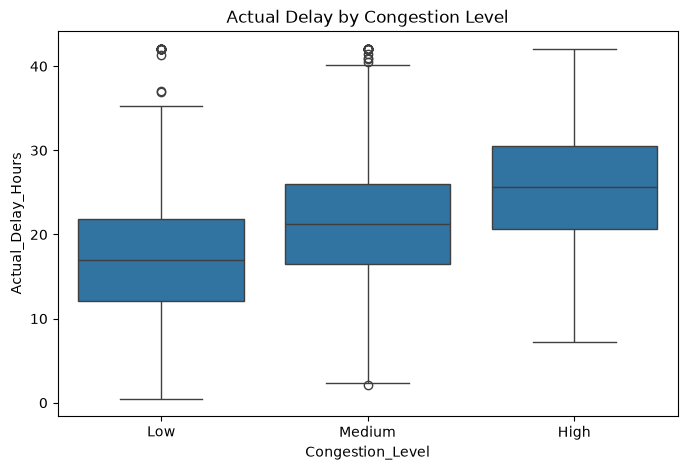

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Congestion_Level",
    y="Actual_Delay_Hours"
)

plt.title("Actual Delay by Congestion Level")

plt.show()

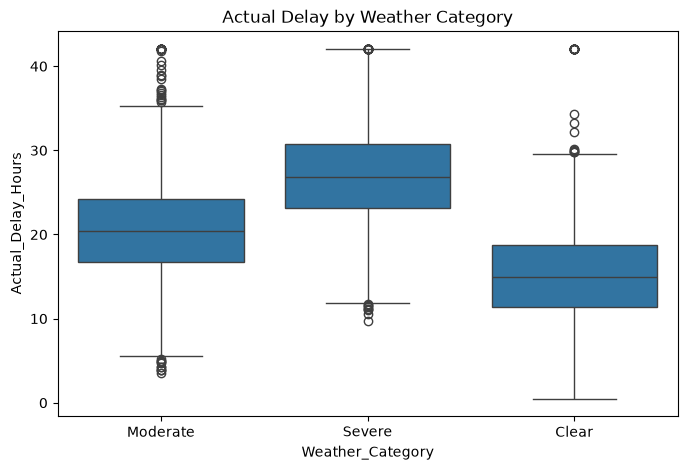

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Weather_Category",
    y="Actual_Delay_Hours"
)

plt.title("Actual Delay by Weather Category")

plt.show()

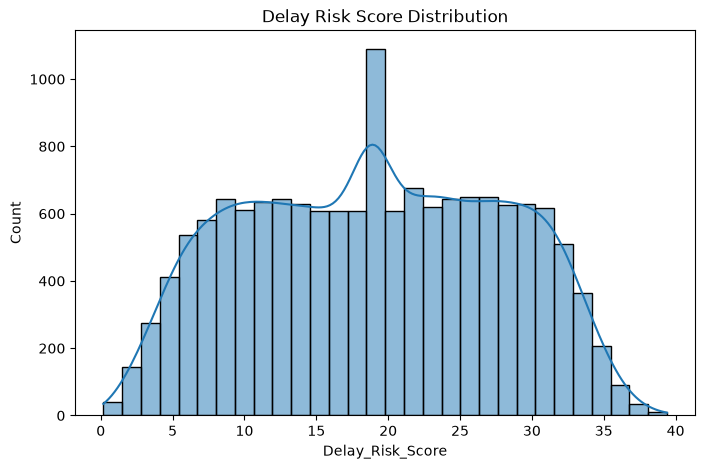

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Delay_Risk_Score"],
    bins=30,
    kde=True
)

plt.title("Delay Risk Score Distribution")

plt.show()

In [28]:
output_path = "../data/processed/vessel_arrival_delay_feature_engineered.csv"

df.to_csv(output_path, index=False)

print(f"Feature-engineered dataset saved to:\n{output_path}")

Feature-engineered dataset saved to:
../data/processed/vessel_arrival_delay_feature_engineered.csv
